In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#Check dataset dimensions:
df.shape

(8807, 12)

In [ ]:
#Check column names:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
#Check data types and non-null values:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#Check missing values:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
#Check duplicate rows:
df.duplicated().sum()

np.int64(0)

In [23]:
#Remove duplicate rows:
df.drop_duplicates(inplace=True)

In [24]:
#verify that duplicates have been removed
df.duplicated().sum()

np.int64(0)

In [9]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    format="%B %d, %Y"
)

In [10]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [11]:
#Create useful date columns
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [12]:
df[["date_added", "year_added", "month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,September
1,2021-09-24,2021.0,September
2,2021-09-24,2021.0,September
3,2021-09-24,2021.0,September
4,2021-09-24,2021.0,September


## 4. Exploratory Data Analysis (EDA)In this section, we analyze Netflix's content library to identify patterns and trends related to content type, release years, countries, genres, ratings, and duration.


### 4.1 Distribution of Movies and TV Shows This analysis compares the number of Movies and TV Shows available in the Netflix dataset.


In [13]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

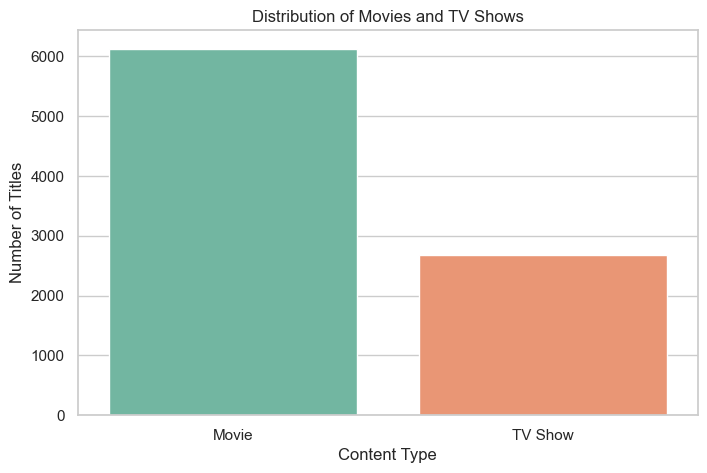

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

#### Insight
Movies make up the majority of the Netflix content in this dataset, while TV Shows represent a smaller portion of the overall catalog.

### 4.2 Content Added to Netflix Over the Years

This analysis examines how the number of titles added to Netflix has changed over time.

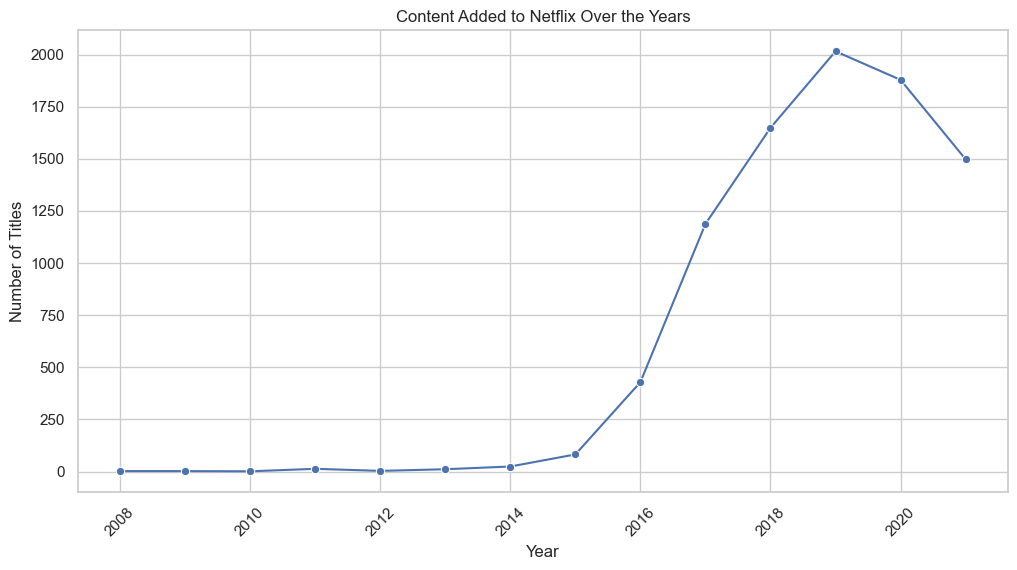

In [16]:
content_by_year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=content_by_year.index,
    y=content_by_year.values,
    marker="o"
)

plt.title("Content Added to Netflix Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

#### Insight

The number of titles added to Netflix increased significantly over the years, showing rapid expansion of the platform's content library. The trend reaches a peak in the later years before declining in the most recent period represented in the dataset.

### 4.3 Top 10 Content-Producing Countries

This analysis identifies the countries with the highest number of titles available in the Netflix dataset.

In [17]:
countries = (
    df["country"]
    .str.split(",")
    .explode()
    .str.strip()
)

top_countries = countries[
    countries != "Unknown"
].value_counts().head(10)

top_countries

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

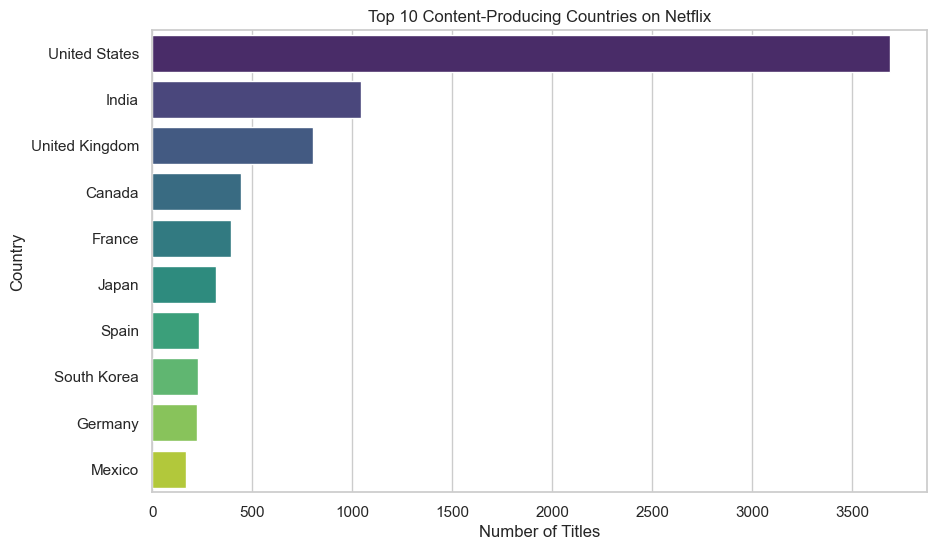

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

#### Insight

The United States contributes the largest number of titles to the Netflix catalog, followed by other major content-producing countries. This shows that while Netflix has a global content library, a significant portion of its content originates from a few leading markets.

### 4.4 Top 10 Genres on Netflix

This analysis identifies the most common genres and content categories available in the Netflix dataset.

In [19]:
genres = (
    df["listed_in"]
    .str.split(",")
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

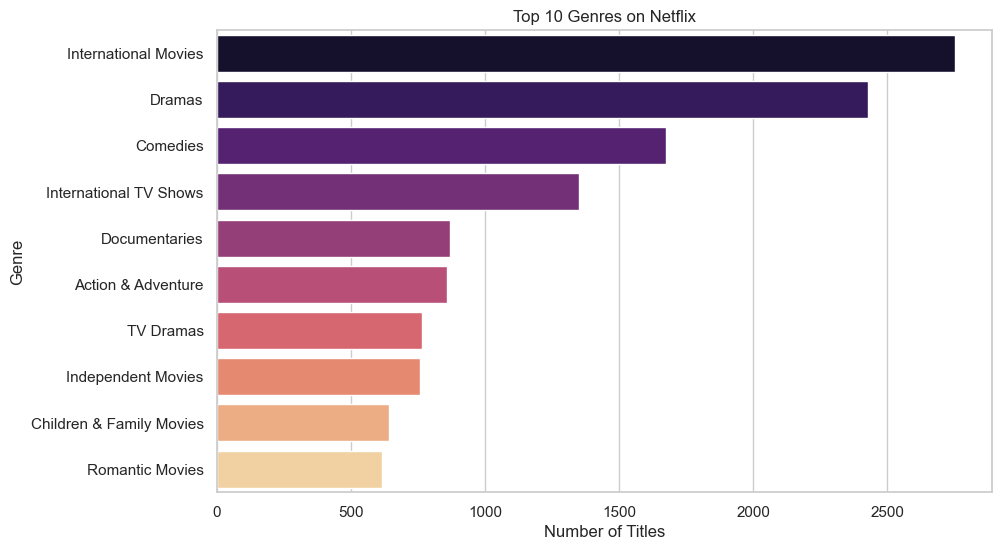

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

#### Insight

The most common genres in the Netflix catalog are dominated by popular categories such as International Movies, Dramas, and Comedies. This indicates a strong focus on globally diverse content and widely popular entertainment genres.

### 4.5 Distribution of Content Ratings

This analysis examines the distribution of content ratings in the Netflix catalog to understand the target audience of the available titles.

In [21]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

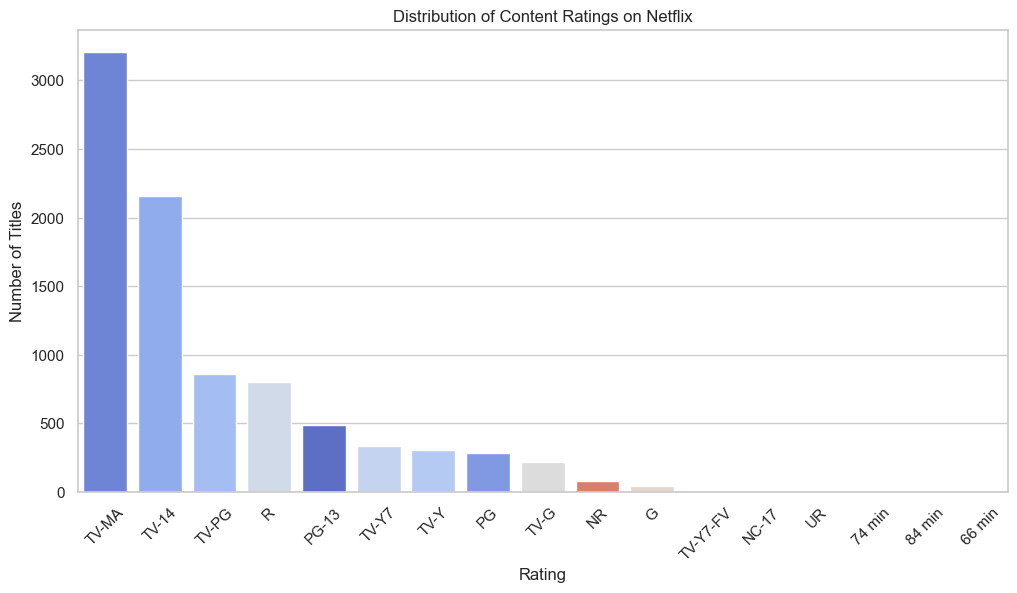

In [23]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index,
    hue="rating",
    palette="coolwarm",
    legend=False
)

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

#### Insight

The Netflix catalog contains a wide range of content ratings. However, mature and teen-oriented ratings account for a significant portion of the available titles, indicating that much of the platform's content is targeted toward older teenagers and adult audiences.

### 4.6 Movie Duration Analysis

This analysis examines the distribution of movie durations to understand the typical length of movies available in the Netflix catalog.

In [26]:
# Select only Movies
movies = df[df["type"] == "Movie"].copy()

# Extract the numeric duration
movies["duration_minutes"] = pd.to_numeric(
    movies["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Remove any rows where duration could not be converted
movies.dropna(subset=["duration_minutes"], inplace=True)

# View summary statistics
movies["duration_minutes"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

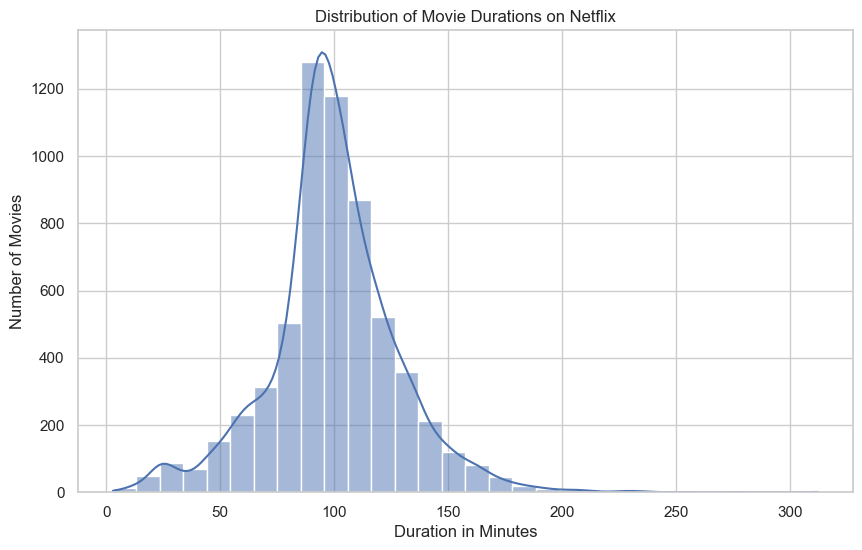

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=movies,
    x="duration_minutes",
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")

plt.show()

#### Insight

Most movies on Netflix are concentrated around typical feature-film lengths, while relatively few titles have extremely short or very long durations. The distribution shows that the majority of movies fall within a common duration range.

### 4.7 Movies vs TV Shows Added Over the Years

This analysis compares the number of Movies and TV Shows added to Netflix each year to understand how the platform's content strategy has evolved over time.

In [28]:
content_type_year = (
    df.groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

content_type_year.head()

,year_added,type,count
0,2008.0,Movie,1
1,2008.0,TV Show,1
2,2009.0,Movie,2
3,2010.0,Movie,1
4,2011.0,Movie,13


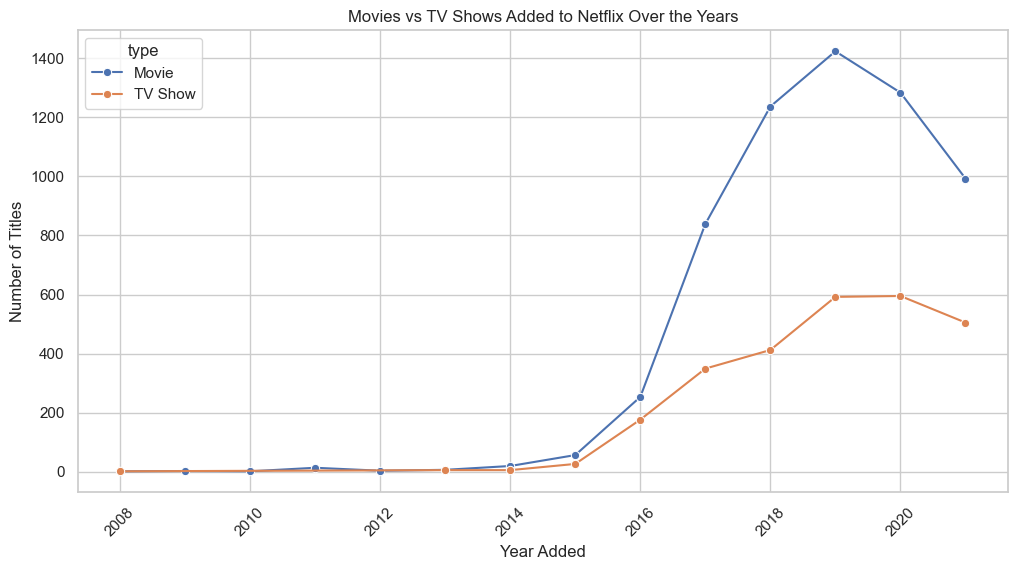

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=content_type_year,
    x="year_added",
    y="count",
    hue="type",
    marker="o"
)
plt.title("Movies vs TV Shows Added to Netflix Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

#### Insight

Both Movies and TV Shows experienced substantial growth in the number of titles added to Netflix over time. Movies generally accounted for a larger number of additions, while TV Shows also showed significant growth as Netflix expanded its content library.

### 4.8 Top 10 Directors on Netflix

This analysis identifies the directors associated with the highest number of titles in the Netflix dataset.

In [30]:
directors = (
    df["director"]
    .str.split(",")
    .explode()
    .str.strip()
)

top_directors = directors[
    directors != "Unknown"
].value_counts().head(10)

top_directors

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64

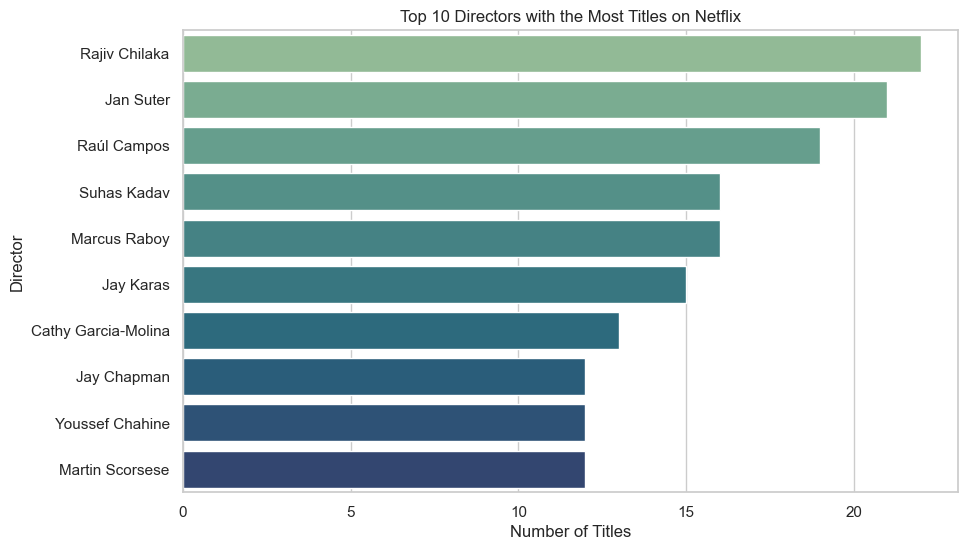

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Directors with the Most Titles on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

#### Insight

A small group of directors have contributed multiple titles to the Netflix catalog. The leading directors have a noticeably higher number of titles, highlighting their significant representation within the dataset.

## 5. Key Insights

The exploratory data analysis of the Netflix dataset revealed several important patterns:

- Movies make up the majority of the Netflix content in the dataset, with substantially more movies than TV shows.
- The number of titles added to Netflix increased significantly over time, reflecting the rapid expansion of the platform's content library.
- The United States is the largest contributor of content, followed by other major content-producing countries.
- International Movies, Dramas, and Comedies are among the most common content categories in the dataset.
- Mature and teen-oriented content ratings represent a significant portion of the Netflix catalog.
- Most movies fall within a typical feature-film duration range, while extremely short or very long movies are less common.
- Movies generally accounted for more yearly additions than TV Shows, although both content types experienced substantial growth.
- Several directors have contributed multiple titles to the Netflix catalog.

## 6. Conclusion

This project explored the Netflix Movies and TV Shows dataset using Python-based data analysis and visualization techniques. The dataset was cleaned and analyzed to identify patterns related to content type, growth over time, countries, genres, ratings, movie duration, and directors.

The analysis shows that Netflix's catalog is dominated by movies and contains content from a diverse range of countries and genres. The platform experienced significant growth in content additions over the years, reflecting its expansion as a global streaming service.

Through this project, I applied data cleaning, data manipulation, exploratory data analysis, and data visualization techniques using NumPy, Pandas, Matplotlib, and Seaborn.